<div align="center">

🎬 Team Final Cuts 🎬

</div>

<div align="center">

#
### Scene Grouping Project

**Aeden Jameson** • **Padmanabh Patil** • **Leon Wan**

---

</div>

# Problem Statement


Media businesses manage large catalogs of video accumulated over many decades, much of which is difficult for media systems to understand, search, summarize, and in general, use in a meaningful way at the story level. Many practical applications such as recap generation, trailer generation, content search, and some ai-assisted editing require story-level understanding. A scene is recognized as the lowest-level unit that carries coherent narrative meaning. Therefore, being able to deconstruct a video into scenes is a fundamental task in enabling valuable use cases in media businesses.

Video scene segmentation is the task of finding the sequence of shots, where a shot is an uninterrupted camera take, within a video that forms a coherent narrative within the broader story. Early work on this task employed unsupervised approaches to detect boundaries via nearest shot clustering. The strongest baseline we could find is Optimal Sequential Grouping [1] by Rotman et al (2017). Circa 2021 early deep learning methods [2,3] took off and made impressive progress. However early deep learning approaches suffered from visual-centric biases. The latest approaches use vision language models that feed shots into VLM’s such as Scene-VLM [4] by Berman et al (2025). Scene-VLM jointly processes frames, transcriptions and other optional metadata to generate boundary predictions. It achieved state of the art benchmarks on MovieNet.  

Along with advancements in scene level understanding, shot level understanding also progressed. OmiShotCut [5] by Wang et al (2026) provides start of the art performance on detecting shot boundaries as well as outputting labels for inter and intra shot transitions. ShotBench [6] provides strong performance across cinematic concepts: shot size, framing angle, lens size, lighting, composition and movement. With these improvements in the shot-level understanding of the grammar of film we explore how well unsupervised methods can now perform. The practical advantage of this approach would be minimal compute requirements to capture scene level boundaries on top of the desired shot-level metadata for modern video inventory systems and their desired capabilities.

---

# Goals

**Completed in this project:**
* Clustering baselines on MovieNet-318: adjacent-distance, constrained merge (OSG DP implemented but skipped at tuning time for speed).
* Modality ablation: **subtitle-only vs. visual (CLIP) vs. multimodal concat**.
* BaSSL-inspired SSL + finetune boundary model on frozen CLIP features (following [9]).
* Comparison to published MovieNet-318 references (LGSS/BaSSL [9], TranS4mer [3], MEGA, Scene-VLM [4]).
* Failure-mode and over-segmentation analysis on sample test movies.
* Shot transition type / ShotBench metadata as merge priors



**Deferred / stretch goals:**
* Gemini (or similar VLM) boundary predictions on a fixed subset.
* Place and character embedding ablations.
* Learned boundary classifier with full end-to-end shot-encoder training.


---

# Implementation Approach

We evaluate **embedding-based clustering** and a **BaSSL-inspired learned boundary model** [9] on the MovieNet-318 benchmark, building on the shot-clustering lineage of Yeung & Yeo [7] and Veneau et al. [8] but using modern pretrained encoders instead of hand-crafted linkage features.

### Tool stack
- **Python 3** with **PyTorch**, **scikit-learn**, **pandas**, and **Jupyter / Google Colab (A100 GPU)**
- **Hugging Face** for CLIP (`openai/clip-vit-base-patch32`) and sentence embeddings (`all-MiniLM-L6-v2`)
- **OmniShotCut** for shot transition labels.
- **ShotVL** for shot type.
- **MovieNet-318** assets: scene labels, train/val/test split, shot timing, subtitles, and 240p keyframes ([Huang et al., ECCV 2020](https://movienet.github.io/); [Rao et al., CVPR 2020](https://movienet.github.io/projects/cvpr20sceneseg.html))

### Models
| Component | Source | Role |
|-----------|--------|------|
| **MiniLM-L6-v2** | Pretrained (Sentence-Transformers) | Subtitle / dialogue shot embeddings |
| **CLIP ViT-B/32** | Pretrained (OpenAI) | Visual shot embeddings (middle keyframe per shot) |
| **Clustering segmenters** | Implemented | Adjacent-distance thresholding, constrained merge, optional OSG dynamic programming |
| **BaSSL-inspired CRN** | Trained by us | 3-layer Transformer + SSL pretext tasks + boundary head (BaSSL [9]) |
| **OmniShotCut** | Pretrained| Shot Transtion Type for Cluster Prior |
| **ShotVL** | Pretrained| Shot Type for Cluster Prior |

We did **not** train a vision-language model from scratch or integrate Gemini/OmiShotCut metadata in this phase; those remain stretch goals.

### Evaluation protocol
- **318 movies** (190 train / 64 val / 64 test), **507,212 shots** total
- **LGSS label policy**: a shot is a boundary if its raw label is `1` or `-1`
- Tune thresholds / merge parameters on **validation**; report **macro-averaged F1** and **average precision (AP)** on the held-out **test** split (64 movies)
- Qualitative review via boundary timelines and predicted-scene keyframe videos on sample test movies
- F1 & AP Scores on BBC Dataset


---

# Exploratory Data Analysis

### Dataset highlights (MovieNet-318)

| Statistic | Value |
|-----------|-------|
| Movies (train / val / test) | 190 / 64 / 64 |
| Total shots | 507,212 |
| LGSS boundary rate | **8.29%** of shots (heavy class imbalance) |
| Raw label `-1` (montage / special cut) | 4,451 shots (0.88%) |
| Mean shots per movie | ~1,570-1,656 by split |
| Subtitle coverage | **~98.5%** of movies |
| Keyframe coverage (our run) | **100%** (318/318) |

**Takeaways:** Scene boundaries are sparse, so threshold-based methods must be tuned carefully. Subtitles and keyframes are available for nearly all benchmark movies, enabling multimodal comparisons. The LGSS convention treats montage markers (`-1`) as boundaries, which affects both training labels and evaluation.


Currently, MovieNet-318 can be considered the standard benchmark for cinematic scene segmentation, with shot-level ground truth and a fixed split enabling comparison to LGSS, TranS4mer, and Scene-VLM. Labels are granular with clear 0/1 semantics and documented remappings in official toolings. Therefore, if clustering is applied and evaluated on MovieNet-318 test data, labels will need to be processed consistently. Needless to say, there is a heavy class imbalance (boundaries are a minority of shots), subjective scene definitions, incomplete subtitle coverage, and cultural/genre bias. Raw -1 codes also require explicit handling. Lastly, the BBC Planet Earth dataset is a different domain in comparison to MovieNet and lacks scene-level ground truth, but contains shot-level ground truth.

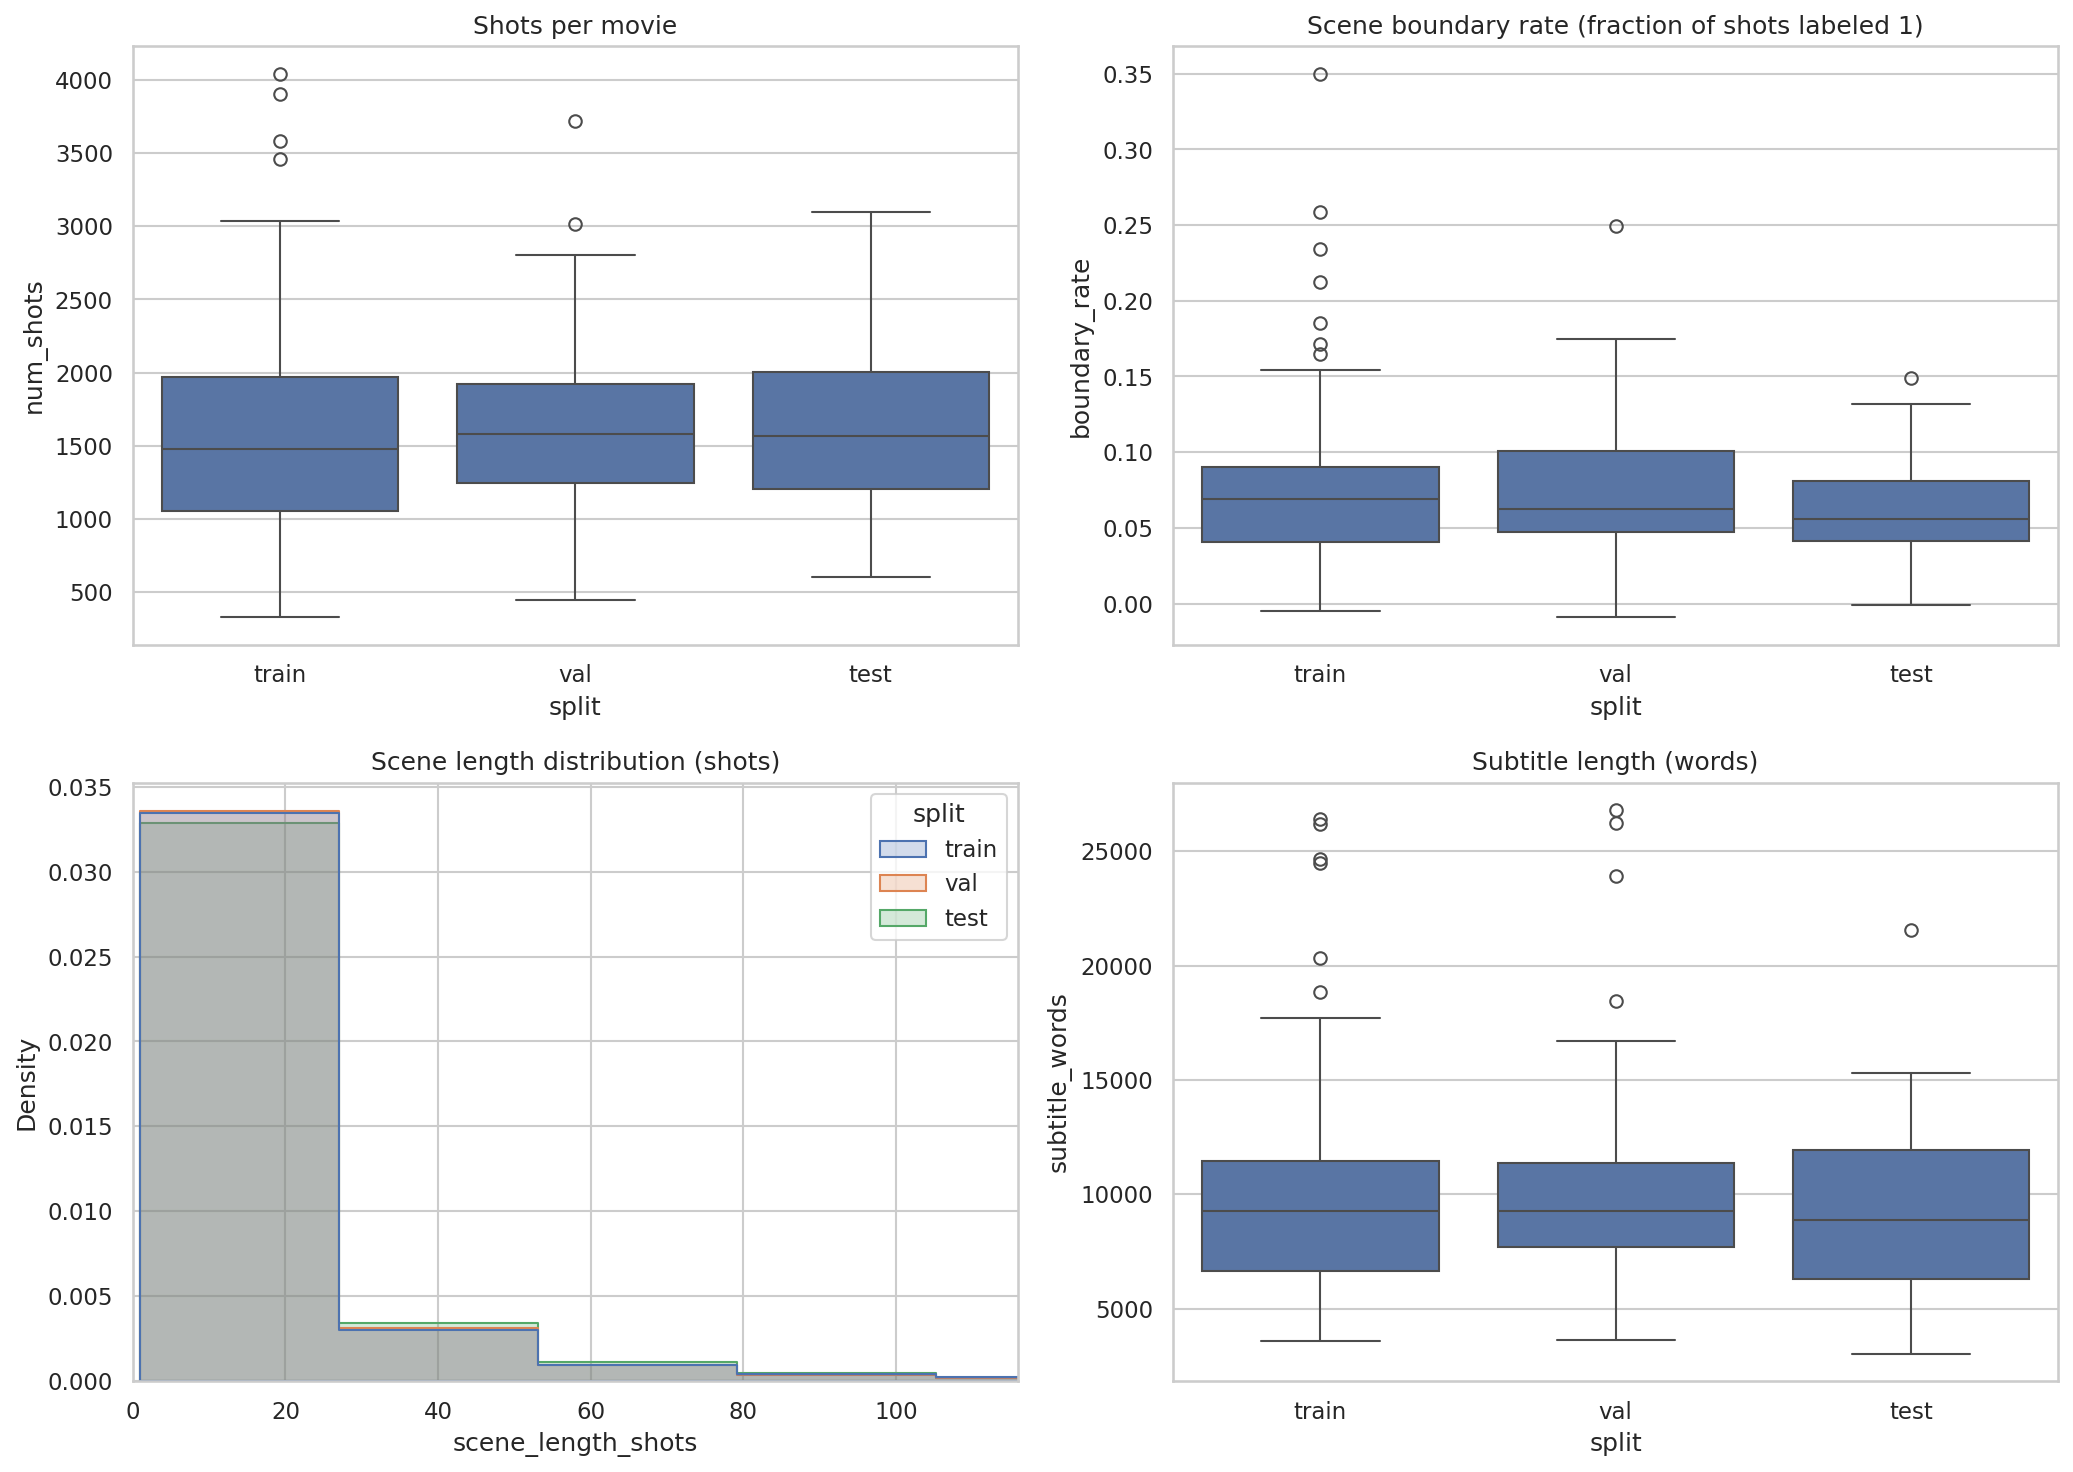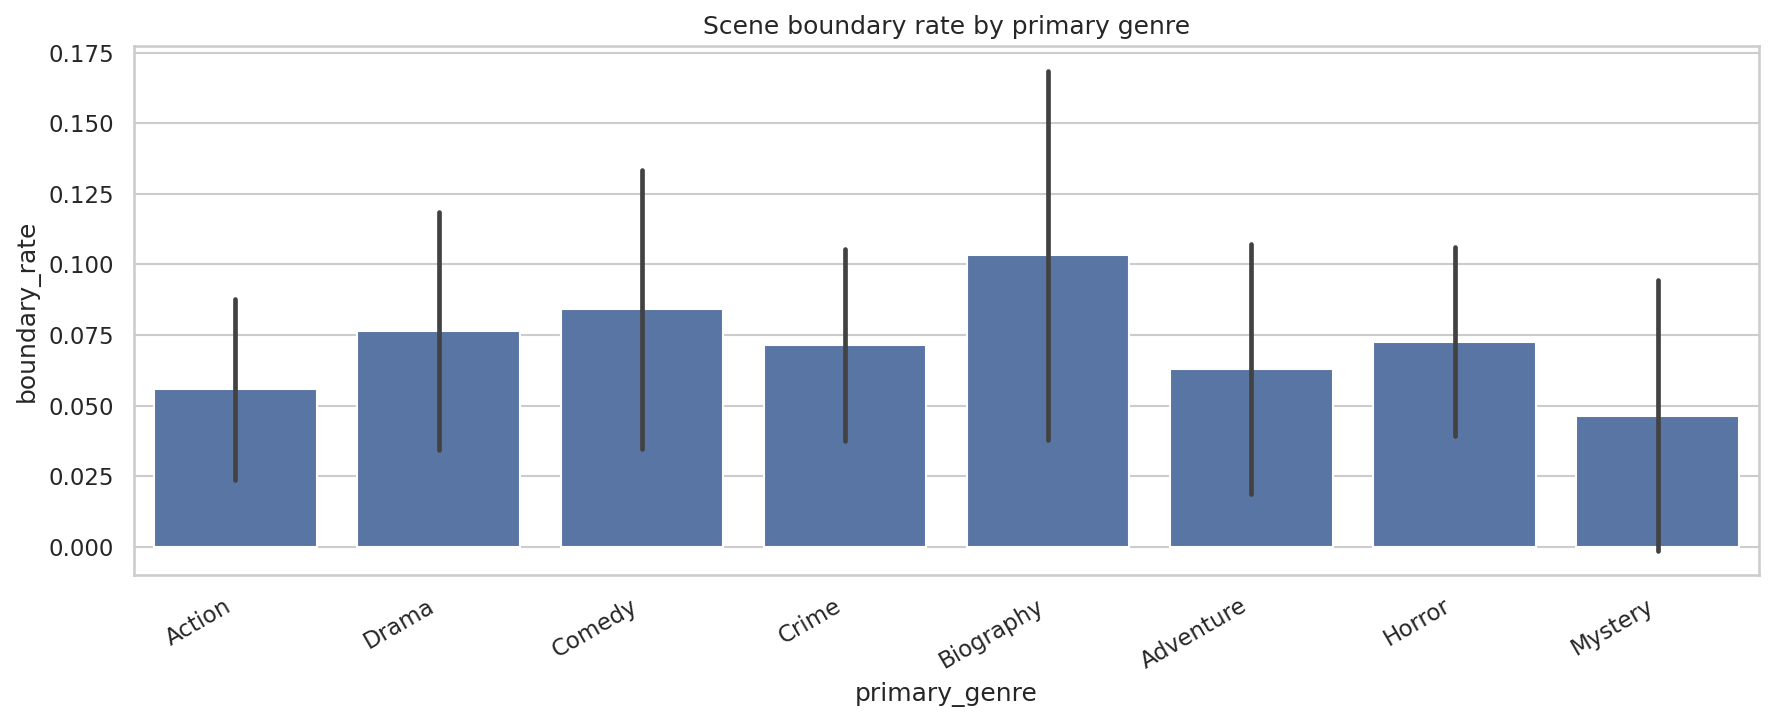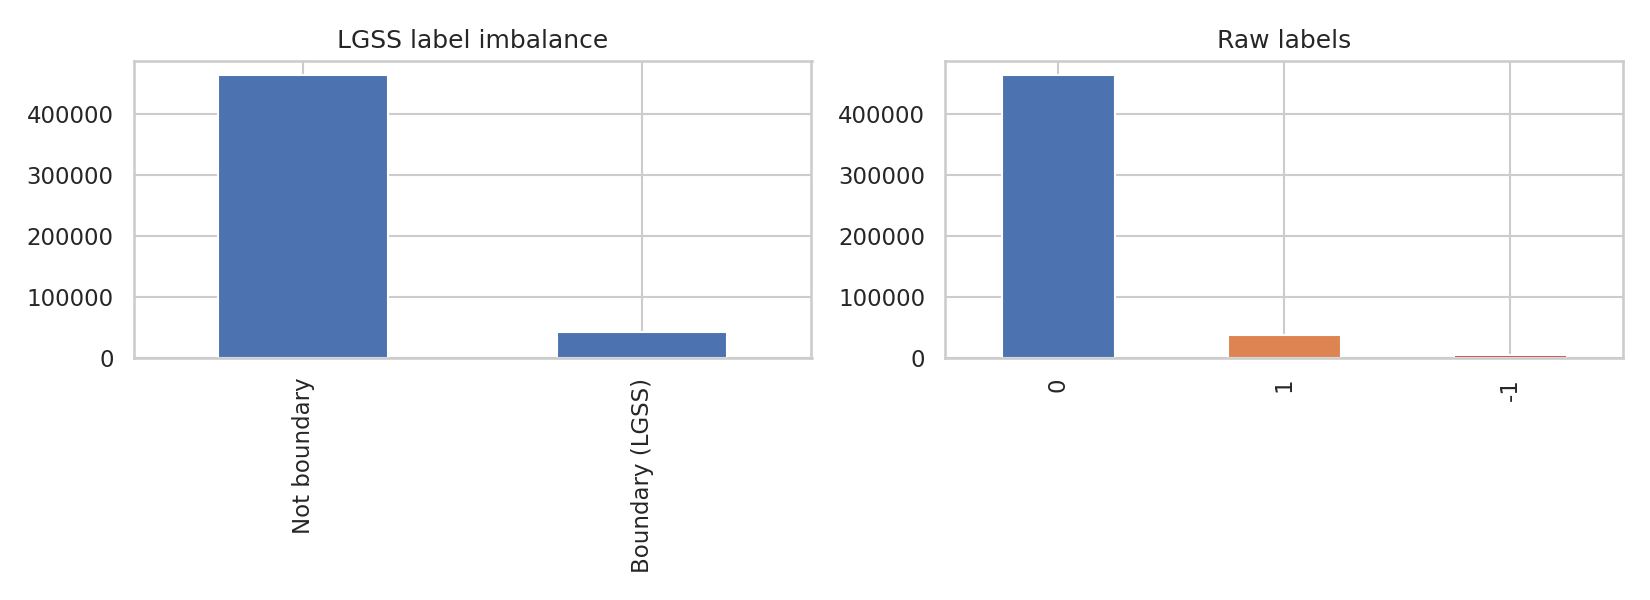---

# Results

All numbers below are **macro-averaged over 64 test movies** on MovieNet-318 (F1 and AP reported as percentages).

### Clustering baselines (`test_keyframes.ipynb`)

Best configuration: **visual (CLIP) + constrained merge** (merge threshold tuned on val).

| Modality | Method | Test F1 | Test AP |
|----------|--------|---------|---------|
| **Visual (CLIP)** | Constrained merge | **24.8%** | **11.6%** |
| Visual (CLIP) | Adjacent distance | 16.1% | 11.6% |
| Multimodal (CLIP + subtitle) | Constrained merge | 15.6% | 9.4% |
| Subtitle (MiniLM) | Constrained merge | 12.7% | 8.1% |
| Subtitle (MiniLM) | Adjacent distance | 12.5% | 8.1% |

Visual features clearly outperform dialogue-only embeddings. Adding subtitles to CLIP **did not help** in our setup (likely because alignment noise dominates).

### BaSSL-inspired pipeline [9] (`test_scene_seg_bassl.ipynb`)

Frozen CLIP features → pseudo-boundary SSL pretrain (12 epochs) → supervised boundary finetune (15 epochs), following the BaSSL [9] recipe adapted to MovieNet-318.

| Method | Split | F1 | AP |
|--------|-------|----|----|
| CLIP adjacent-distance (clustering) | test | 15.8% | 11.6% |
| **BaSSL-inspired (SSL + finetune)** | val | 30.6% | 27.1% |
| **BaSSL-inspired (SSL + finetune)** | test | **29.3%** | **26.1%** |

SSL + finetune improves test F1 by **~13.5 points** over the CLIP clustering baseline in the same notebook.

### Comparison to published MovieNet-318 references

| Method | Reported test F1 | Reported AP |
|--------|------------------|-------------|
| BaSSL [9] | 47.0% | 57.4% |
| TranS4mer | 48.4% | 60.8% |
| MEGA | 55.3% | 58.6% |
| Scene-VLM (Berman et al., 2026) | 62.1% | 66.8% |
| **Our best clustering** | 24.8% | 11.6% |
| **Our BaSSL-inspired model** | 29.3% | 26.1% |

Our methods remain **well below** published supervised baselines [3,4,9], but our BaSSL-inspired pipeline closes part of the gap over pure clustering without end-to-end shot-encoder training.

### Comparsion of Adjacent Only w/ Priors on BBC (unsupervised_approaches.ipynb)

| Method | Reported test F1 | Reported AP |
|--------|------------------|-------------|
| Adjacent only w/ shot type prior|	0.3674 | 0.2809
| Adjacent only w/ establishing shot priort	0.3515| 0.2763


### Qualitative observations (sample test movies)
- Predicted scene counts often **exceed** ground truth (e.g., 143 predicted vs. 93 GT scenes on one movie), indicating **over-segmentation**.
- Per-movie boundary F1 on inspected examples ranged from **~0.16 to 0.47**, showing high variance across film style and pacing.

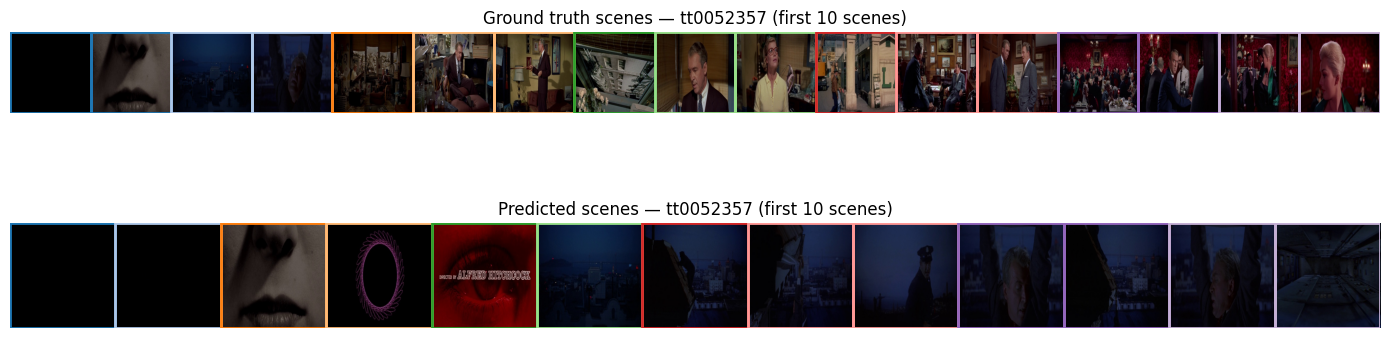

GT scenes: 93 | Pred scenes: 143 | shots: 1100
Shot-level boundary F1 (this movie): 0.315

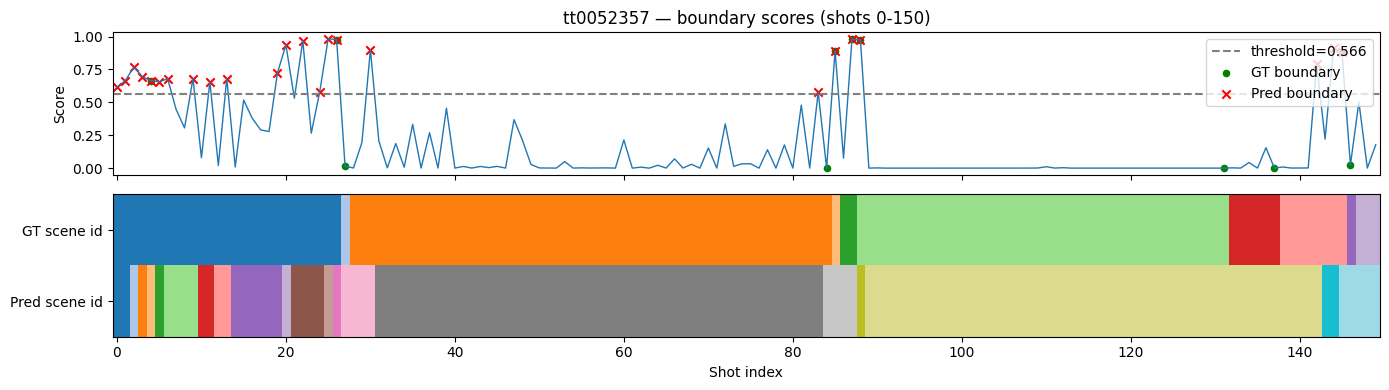



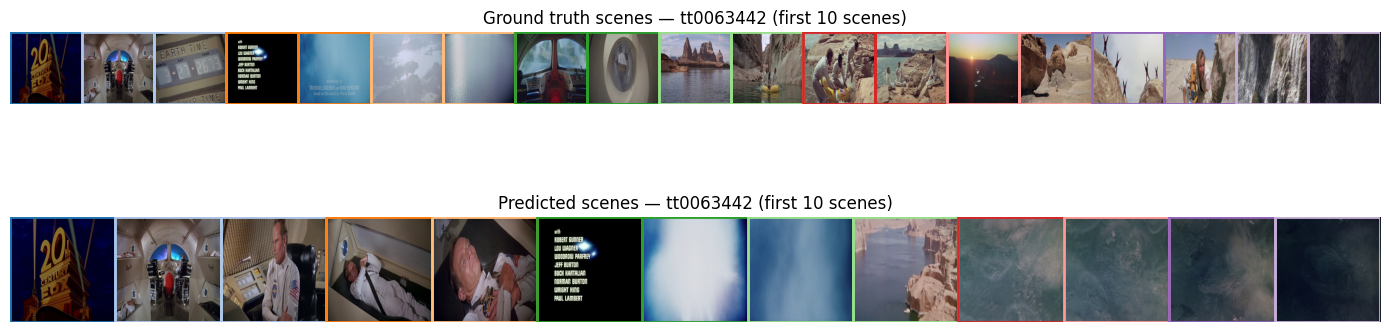

GT scenes: 36 | Pred scenes: 136 | shots: 1143
Shot-level boundary F1 (this movie): 0.164

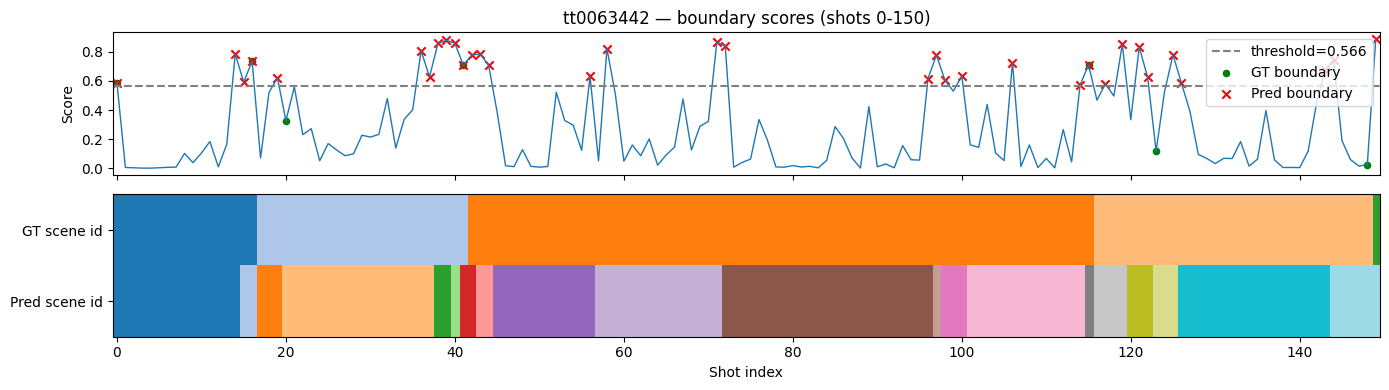

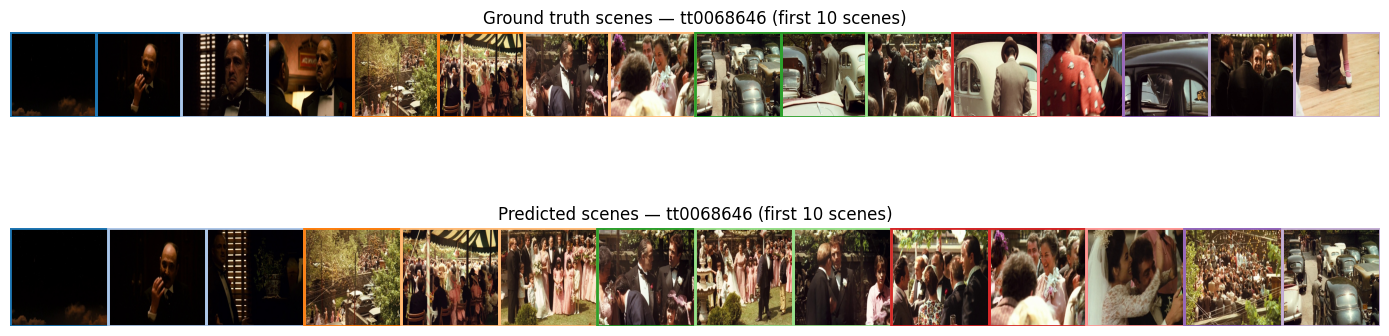

GT scenes: 197 | Pred scenes: 367 | shots: 1249
Shot-level boundary F1 (this movie): 0.472

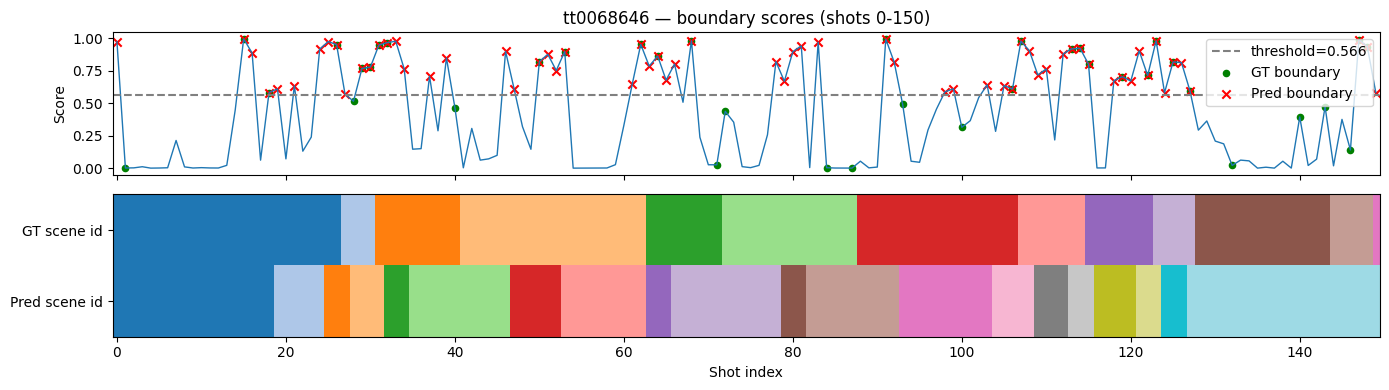

---

# Discussion

### Interpretation
- **Visual CLIP embeddings carry most of the signal** for unsupervised grouping (24.8% test F1 with constrained merge vs. ~12.6% for subtitle-only). This aligns with the intuition that cinematic scene changes are often visible even when dialogue is continuous.
- **Multimodal concatenation underperformed visual-only clustering** in our experiments, suggesting naive fusion without alignment-aware training is insufficient.
- Our **BaSSL-inspired pipeline [9] (29.3% test F1)** improves over clustering by modeling **temporal context** and using **pseudo-boundary self-supervision** before finetuning on sparse labels. Gains are real but modest relative to published end-to-end methods [3,4,9] (47–62% F1).
- Qualitative review shows frequent **over-segmentation** (too many predicted scenes), especially on fast-cut sequences.
- Shot type and transition priors didn't help with find scene boundaries.

### What this work shows
- Modern off-the-shelf shot embeddings + simple segmenters produce a **reproducible baseline** on MovieNet-318 without training a shot encoder.
- A **lightweight contextual model** on frozen CLIP features can beat pure clustering without the compute cost of full VLM pipelines.
- The benchmark gap to Scene-VLM and TranS4mer remains **large**, confirming that scene segmentation still requires rich multimodal reasoning beyond pairwise shot similarity.

### Limitations (what it does not show)
- We did **not** run Gemini/VLM boundary prediction or shot-transition metadata ablations from the original proposal.
- **OSG dynamic programming** was disabled during tuning for speed; it may change clustering rankings.
- Labels are **subjective** and **imbalanced**; F1 alone may under-reward partial boundary alignment.
- Results use **240p keyframes** and a single middle frame per shot — not full temporal video context.
- MovieNet is **fiction-heavy**; generalization to news, sports, or documentary (e.g., BBC Planet Earth) is untested here.

### Ethical considerations
- MovieNet footage is **copyright-protected**; we use keyframes under academic research terms only and do not redistribute raw video.
- Automated scene segmentation could affect **archival labor** (indexing, logging) — benefits for search/recap should be weighed against workforce impacts.
- Errors in boundary detection may skew **downstream summarization or editing tools**, potentially misrepresenting narrative structure; human review remains important for high-stakes cataloging.


---

# Future Considerations

1. **Integrate shot-level metadata** (transition type, shot size, framing from OmiShotCut / ShotBench) as merge priors or auxiliary SSL tasks.
2. **VLM boundary baseline** - evaluate Gemini or Scene-VLM-style multimodal prompting on the same 64-movie test split for a fair comparison to clustering.
3. **End-to-end or partial finetuning** of the visual encoder (last CLIP blocks) rather than frozen features only.
4. **Better multimodal fusion** - cross-attention between subtitle tokens and visual features instead of concatenation.
5. **Post-processing** - minimum scene length constraints and hysteresis thresholding to reduce over-segmentation observed qualitatively.
6. **Domain transfer study** - evaluate on non-fiction or user-generated video where scene boundaries may differ from Hollywood pacing.


---

# References

[1] Rotman, D., Porat, D., & Ashour, G. (2017). Optimal sequential grouping for robust video scene detection using multiple modalities. International Journal of Semantic Computing, 11(2), 193–208. https://doi.org/10.1142/S1793351X17400086

[2] Chen, S., Nie, X., Fan, D., Zhang, D., Bhat, V., & Hamid, R. (2021). Shot contrastive self-supervised learning for scene boundary detection. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) (pp. 9796–9805).

[3] Islam, M. M., Hasan, M., Athrey, K. S., Braskich, T., & Bertasius, G. (2023). Efficient movie scene detection using state-space transformers. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) (pp. 18749–18758).

[4] Berman, N., Botach, A., Ben-Baruch, E., Haviv Hakimi, S., Gendler, A., Naiman, I., Yosef, E., & Kviatkovsky, I. (2026). Scene-VLM: Multimodal video scene segmentation via vision-language models. arXiv. https://doi.org/10.48550/arXiv.2512.21778

[5] Wang, B., Xu, G., Tang, Z., Zhang, J., & Cheng, Z. (2026). OmniShotCut: Holistic relational shot boundary detection with shot-query transformer. arXiv preprint arXiv:2604.24762.

[6] Liu, H., He, J., Jin, Y., Zheng, D., Dong, Y., Zhang, F., Huang, Z., He, Y., Li, Y., Chen, W., Qiao, Y., Ouyang, W., Zhao, S., & Liu, Z. (2025). ShotBench: Expert-level cinematic understanding in vision-language models. arXiv. https://doi.org/10.48550/arXiv.2506.21356

[7] Yeung, M. M., & Yeo, B.-L. (1996). Time-constrained clustering for segmentation of video into story units. In Proceedings of the 13th International Conference on Pattern Recognition (Vol. 3, pp. 375–380). IEEE. https://doi.org/10.1109/ICPR.1996.546973

[8] Veneau, E., Ronfard, R., & Bouthemy, P. (2000). From video shot clustering to sequence segmentation. In Proceedings of the 15th International Conference on Pattern Recognition (Vol. 4, pp. 254–257). IEEE. https://doi.org/10.1109/ICPR.2000.902907

[9] Mun, J., Shin, M., Han, G., Lee, S., Ha, S., Lee, J., & Kim, E.-S. (2022). BaSSL: Boundary-aware self-supervised learning for video scene segmentation. In Proceedings of the Asian Conference on Computer Vision (ACCV) (pp. 4027–4043). https://arxiv.org/abs/2201.05277


---

### AI Usage Statement

Artificial Intelligence (AI) tools were used to assist with brainstorming, content refinement, coding support, and proofreading during this project. All AI-generated outputs were reviewed, validated, and edited by the authors. The final project reflects our own understanding, analysis, and implementation, and we accept full responsibility for its content.

---